In [ ]:
# ============================================================
# RANDOM FOREST
# 11 FEATURES
# SEED 42 / 43 / 44
# ============================================================

!pip install -q gdown

import gdown

gdown.download(
    id="1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv",
    output="HPV2025.xlsx",
    quiet=False
)

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=43):

    random.seed(seed)

    np.random.seed(seed)

    os.environ["PYTHONHASHSEED"]=str(seed)

SEED=43

seed_everything(SEED)

# ------------------------------------------------------------
# Read Dataset
# ------------------------------------------------------------

df=pd.read_excel("HPV2025.xlsx")

df=df.dropna(subset=["HPV Status"])

tobacco_mode=df["Tobacco Consumption"].mode()[0]

df["Tobacco Consumption"]=df[
"Tobacco Consumption"
].fillna(tobacco_mode)

alcohol_mode=df["Alcohol Consumption"].mode()[0]

df["Alcohol Consumption"]=df[
"Alcohol Consumption"
].fillna(alcohol_mode)

df=df.drop(
columns=[
"PatientID",
"CenterID",
"Task 1",
"Task 2",
"Task 3"
]
)

df=df.dropna()

print(df.shape)

# ------------------------------------------------------------
# Encode stages
# ------------------------------------------------------------

df["T-stage"]=df["T-stage"].replace({
"T0":0,
"T1":1,
"T2":2,
"T3":3,
"T4":4
})

df["N-stage"]=df["N-stage"].replace({
"N0":0,
"N1":1,
"N2":2,
"N3":3
})

df["M-stage"]=df["M-stage"].replace({
"M0":0,
"M1":1
})

# ------------------------------------------------------------
# Features
# ------------------------------------------------------------

X=df[
[
"Age",
"Gender",
"Tobacco Consumption",
"Alcohol Consumption",
"Performance Status",
"Relapse",
"RFS",
"Treatment",
"T-stage",
"N-stage",
"M-stage"
]
]

y=df["HPV Status"]

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.20,

random_state=SEED

)

print("\nTrain samples:")

print(y_train.value_counts())

print("\nTest samples:")

print(y_test.value_counts())

# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# ------------------------------------------------------------
# SMOTE
# ------------------------------------------------------------

smote=SMOTE(random_state=SEED)

X_train_smote,y_train_smote=smote.fit_resample(

X_train,
y_train

)

print("\nAfter SMOTE:")

print(pd.Series(y_train_smote).value_counts())


# ------------------------------------------------------------
# Decision Tree Model
# ------------------------------------------------------------

model = RandomForestClassifier(

    n_estimators=100,

    random_state=SEED

)

model.fit(

    X_train_smote,

    y_train_smote

)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted = model.predict(

    X_test

)

probabilities = model.predict_proba(

    X_test

)[:,1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()

print("Classification Report\n")

print(

    classification_report(

        y_test,

        predicted,

        digits=4

    )

)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(

    y_test,

    predicted

)

print("Confusion Matrix")

print(cm)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = (

    (predicted == y_test).sum()

    /

    len(y_test)

)

bal_acc = balanced_accuracy_score(

    y_test,

    predicted

)

f1 = f1_score(

    y_test,

    predicted

)

auc = roc_auc_score(

    y_test,

    probabilities

)

print()

print(f"Accuracy:            {accuracy:.4f}")

print(f"Balanced Accuracy:   {bal_acc:.4f}")

print(f"F1-score:            {f1:.4f}")

print(f"AUC:                 {auc:.4f}")



# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()

print("====================================")

print("RANDOM FOREST SUMMARY")

print("====================================")

print("Model : Random Forest")

print("Input Features : 11")

print("Learning Rate : N/A")

print("Optimiser : N/A")

print("Class Weights : None")

print("SMOTE : Yes")

print("Training Patients :", len(y_train))

print("Test Patients :", len(y_test))

print("Training after SMOTE :", len(y_train_smote))

print("Seed :", SEED)

print()

print("Final Results")

print("---------------------------")

print(f"Accuracy            : {accuracy:.4f}")

print(f"Balanced Accuracy   : {bal_acc:.4f}")

print(f"F1-score            : {f1:.4f}")

print(f"AUC                 : {auc:.4f}")

print()

print("Confusion Matrix")

print(cm)

print()

print("Analysis Complete.")

Downloading...
From: https://drive.google.com/uc?id=1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv
To: /content/HPV2025.xlsx
100%|██████████| 66.0k/66.0k [00:00<00:00, 14.8MB/s]


(423, 12)

Train samples:
HPV Status
1.0    321
0.0     17
Name: count, dtype: int64

Test samples:
HPV Status
1.0    79
0.0     6
Name: count, dtype: int64

After SMOTE:
HPV Status
1.0    321
0.0    321
Name: count, dtype: int64


/tmp/ipykernel_1353/820256158.py:91: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["T-stage"]=df["T-stage"].replace({
/tmp/ipykernel_1353/820256158.py:99: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["N-stage"]=df["N-stage"].replace({
/tmp/ipykernel_1353/820256158.py:106: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_d


Classification Report

              precision    recall  f1-score   support

         0.0     0.2500    0.1667    0.2000         6
         1.0     0.9383    0.9620    0.9500        79

    accuracy                         0.9059        85
   macro avg     0.5941    0.5643    0.5750        85
weighted avg     0.8897    0.9059    0.8971        85

Confusion Matrix
[[ 1  5]
 [ 3 76]]

Accuracy:            0.9059
Balanced Accuracy:   0.5643
F1-score:            0.9500
AUC:                 0.8439

RANDOM FOREST SUMMARY
Model : Random Forest
Input Features : 11
Learning Rate : N/A
Optimiser : N/A
Class Weights : None
SMOTE : Yes
Training Patients : 338
Test Patients : 85
Training after SMOTE : 642
Seed : 43

Final Results
---------------------------
Accuracy            : 0.9059
Balanced Accuracy   : 0.5643
F1-score            : 0.9500
AUC                 : 0.8439

Confusion Matrix
[[ 1  5]
 [ 3 76]]

Analysis Complete.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Preparing LIME...

LIME Explainer Created Successfully

Actual Class    : 1
Predicted Class : 1

LIME Feature Contributions

RFS > 0.08                                    0.3994
T-stage <= -0.12                              0.3582
M-stage <= -0.05                              0.0454
-0.86 < Tobacco Consumption <= 1.17           -0.0429
N-stage <= -1.13                              -0.0315
Age <= -0.56                                  0.0185
-1.17 < Alcohol Consumption <= 0.74           -0.0176
Performance Status <= -0.82                   -0.0110
Relapse <= -0.46                              -0.0001
Gender <= 0.37                                0.0000
Treatment <= 0.47                             0.0000


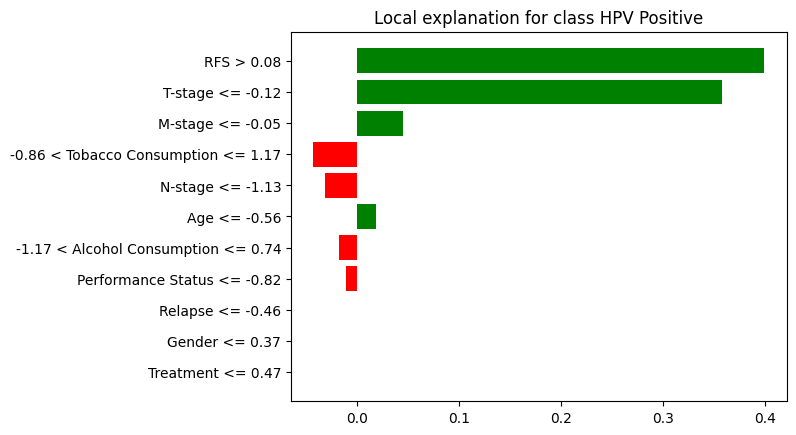

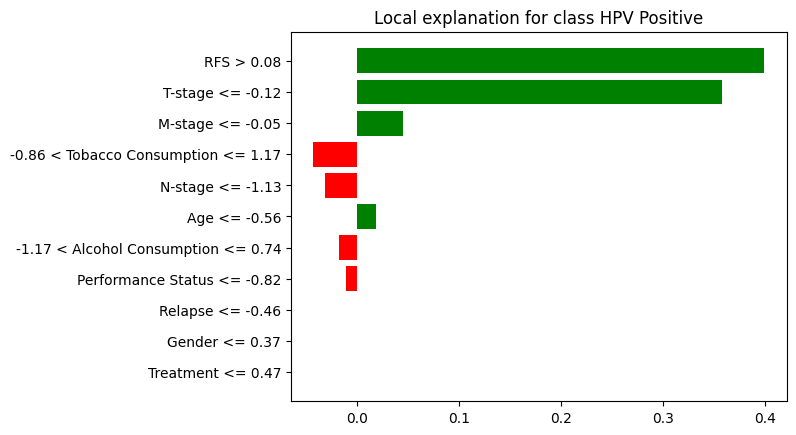

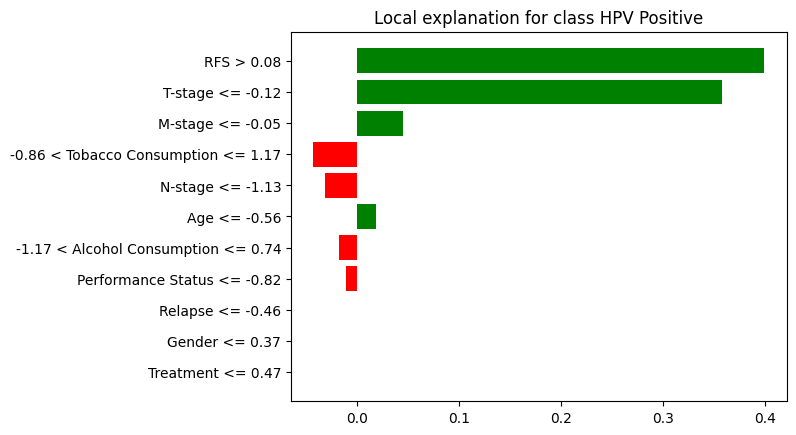

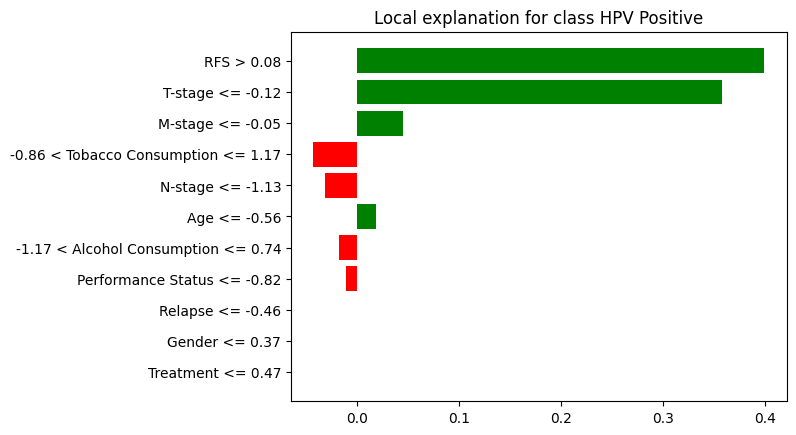

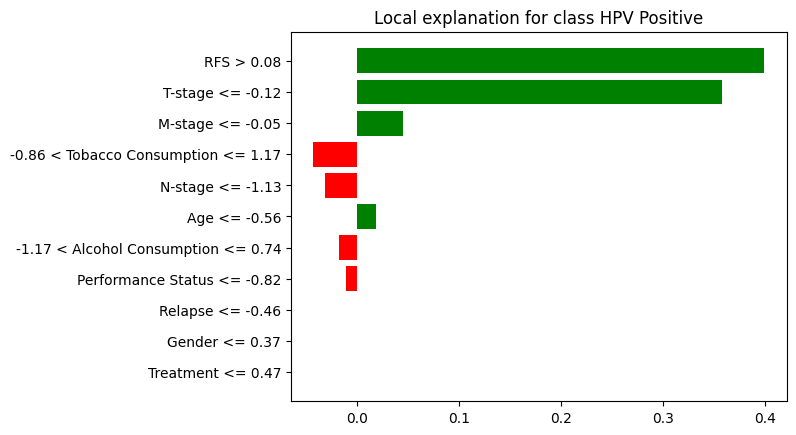

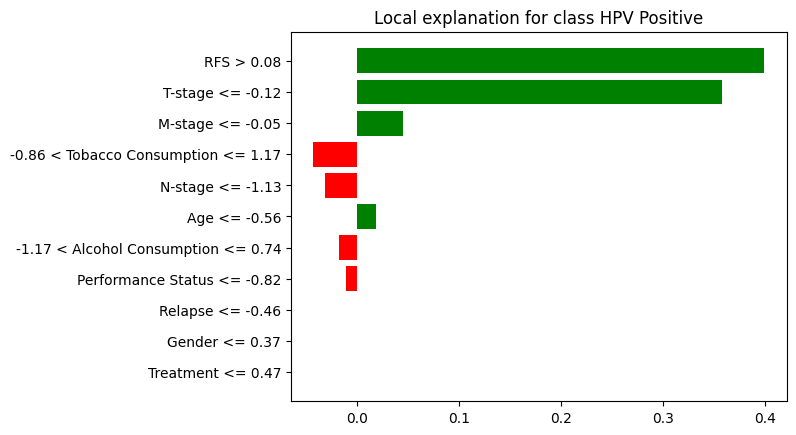

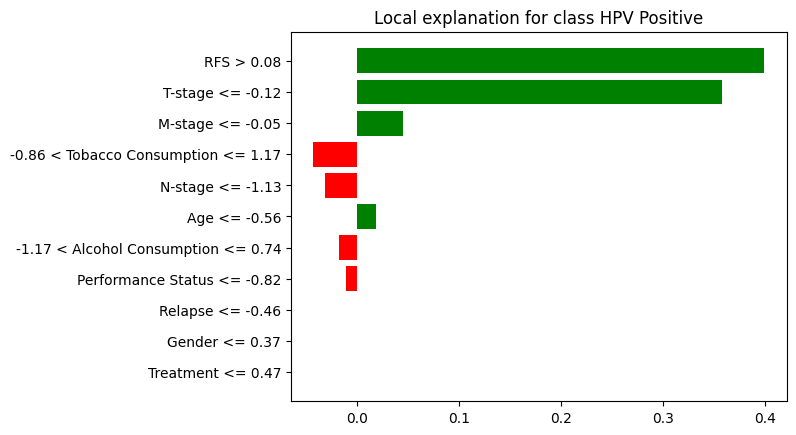

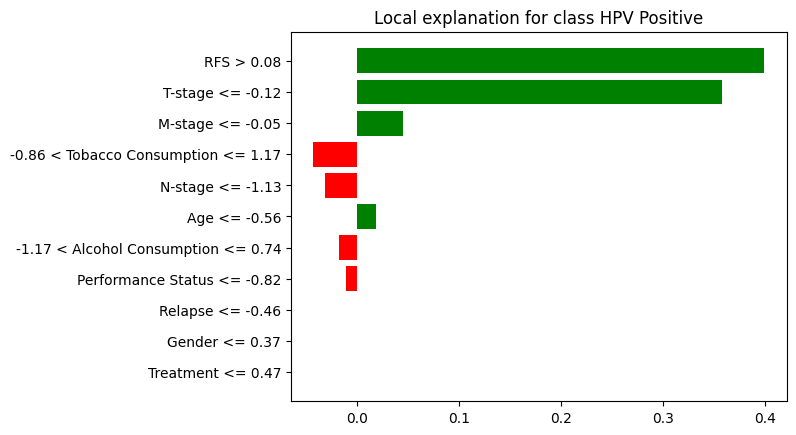

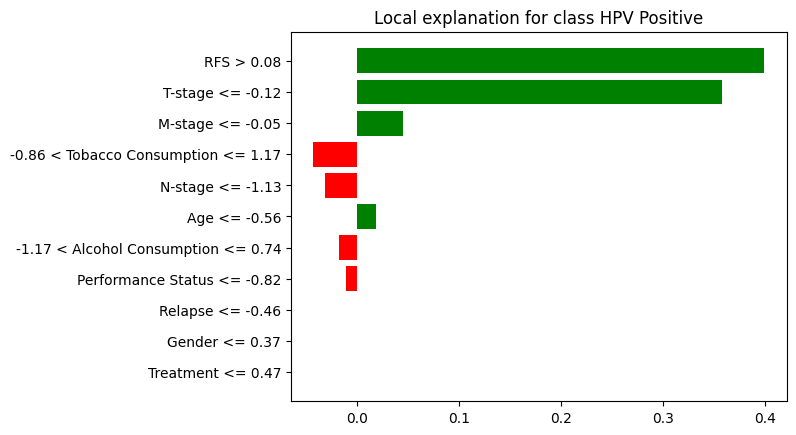

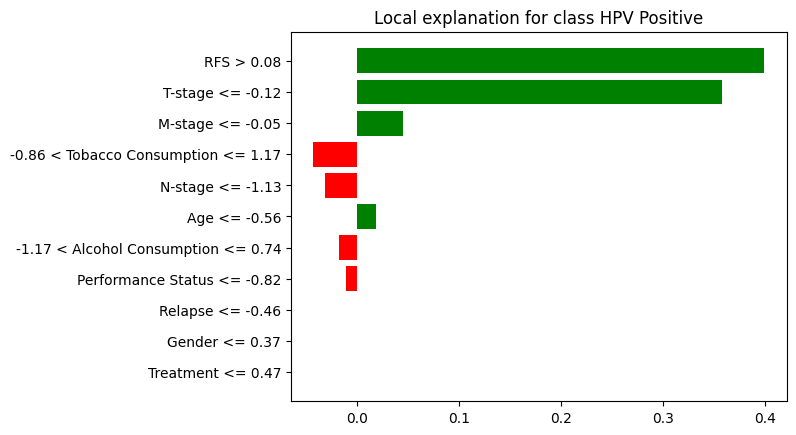

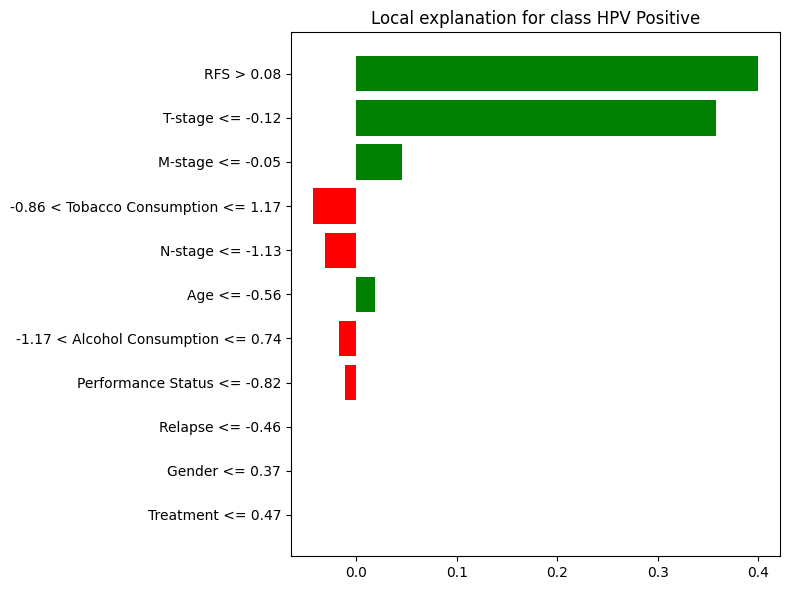


LIME ANALYSIS COMPLETE
Model : Random Forest
Seed : 43
Patient Explained : 0

Generated Files
----------------------------
LIME_RandomForest_Seed43.png
LIME_RandomForest_Seed43.html

Analysis Complete.


In [ ]:
# ============================================================
# LIME ANALYSIS
# RANDOM FOREST
# SEED 43
# ============================================================

!pip install -q lime

import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

print("Preparing LIME...")

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

class_names = [

    "HPV Negative",
    "HPV Positive"

]

explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=X_train_smote,

    feature_names=feature_names,

    class_names=class_names,

    mode="classification",

    discretize_continuous=True,

    random_state=43

)

print()

print("LIME Explainer Created Successfully")
# ============================================================
# Explain One Patient
# ============================================================

patient = 0

exp = explainer.explain_instance(

    X_test[patient],

    model.predict_proba,

    num_features=11

)

prediction = model.predict(

    X_test[patient].reshape(1,-1)

)[0]

actual = y_test.iloc[patient]

print()

print("Actual Class    :", int(actual))

print("Predicted Class :", int(prediction))

print()

print("LIME Feature Contributions\n")

for feature, weight in exp.as_list():

    print(f"{feature:<45} {weight:.4f}")
    fig = exp.as_pyplot_figure()

fig.set_size_inches(8,6)

plt.tight_layout()

plt.savefig(

    "LIME_RandomForest_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

exp.save_to_file(

    "LIME_RandomForest_Seed43.html"

)

print()

print("====================================")

print("LIME ANALYSIS COMPLETE")

print("====================================")

print("Model : Random Forest")

print("Seed : 43")

print("Patient Explained :", patient)

print()

print("Generated Files")

print("----------------------------")

print("LIME_RandomForest_Seed43.png")

print("LIME_RandomForest_Seed43.html")

print()

print("Analysis Complete.")

Preparing Tree SHAP...
Training Shape : (642, 11)
Test Shape     : (85, 11)

Tree SHAP Explainer Created Successfully

Calculating SHAP values...
Done!

SHAP Shape : (85, 11)


/tmp/ipykernel_1353/2498307667.py:84: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


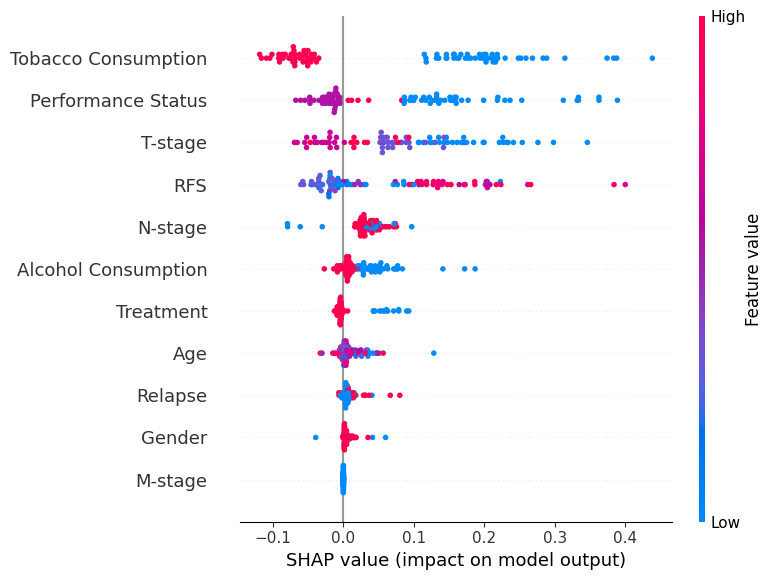

/tmp/ipykernel_1353/2498307667.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


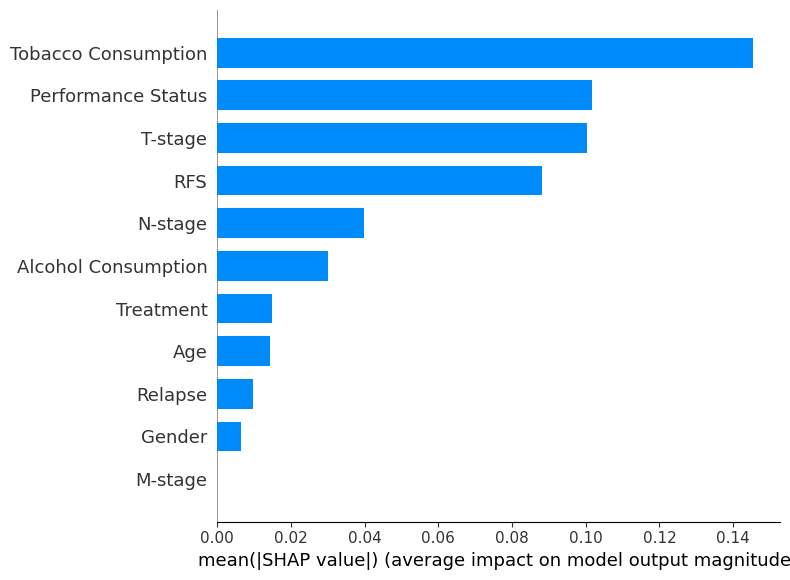


Saved:
SHAP_Summary_RandomForest_Seed43.png
SHAP_Bar_RandomForest_Seed43.png

Creating SHAP Feature Importance...

GLOBAL SHAP FEATURE IMPORTANCE
--------------------------------
                Feature  Mean Absolute SHAP Value
2   Tobacco Consumption                  0.145456
4    Performance Status                  0.101711
8               T-stage                  0.100471
6                   RFS                  0.088150
9               N-stage                  0.039738
3   Alcohol Consumption                  0.030041
7             Treatment                  0.014762
0                   Age                  0.014405
5               Relapse                  0.009626
1                Gender                  0.006382
10              M-stage                  0.000006

Top 11 SHAP Features
------------------------------
 1. Tobacco Consumption         0.145456
 2. Performance Status          0.101711
 3. T-stage                     0.100471
 4. RFS                         0.088150
 5.

In [ ]:
# ============================================================
# SHAP ANALYSIS
# RANDOM FOREST
# TREE SHAP
# SEED 43
# ============================================================

!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Preparing Tree SHAP...")

feature_names = [

    "Age",
    "Gender",
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Relapse",
    "RFS",
    "Treatment",
    "T-stage",
    "N-stage",
    "M-stage"

]

print("Training Shape :", X_train_smote.shape)
print("Test Shape     :", X_test.shape)

explainer = shap.TreeExplainer(model)

print()

print("Tree SHAP Explainer Created Successfully")

# ============================================================
# Calculate SHAP Values
# ============================================================

print()

print("Calculating SHAP values...")

shap_values = explainer.shap_values(X_test)

print("Done!")

# ------------------------------------------------------------
# Handle different SHAP output formats
# ------------------------------------------------------------

if isinstance(shap_values, list):

    shap_values_plot = shap_values[1]

else:

    shap_values = np.array(shap_values)

    if len(shap_values.shape) == 3:

        shap_values_plot = shap_values[:, :, 1]

    else:

        shap_values_plot = shap_values

print()

print("SHAP Shape :", shap_values_plot.shape)

# ============================================================
# SHAP Summary Plot
# ============================================================

plt.figure(figsize=(8,5))

shap.summary_plot(

    shap_values_plot,

    X_test,

    feature_names=feature_names,

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Summary_RandomForest_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ============================================================
# SHAP Bar Plot
# ============================================================

plt.figure(figsize=(6,5))

shap.summary_plot(

    shap_values_plot,

    X_test,

    feature_names=feature_names,

    plot_type="bar",

    show=False

)

plt.tight_layout()

plt.savefig(

    "SHAP_Bar_RandomForest_Seed43.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print()

print("Saved:")

print("SHAP_Summary_RandomForest_Seed43.png")

print("SHAP_Bar_RandomForest_Seed43.png")

# ============================================================
# Create SHAP Feature Importance
# ============================================================

print()

print("Creating SHAP Feature Importance...")

mean_shap = np.abs(shap_values_plot).mean(axis=0)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean Absolute SHAP Value": mean_shap

})

importance = importance.sort_values(

    by="Mean Absolute SHAP Value",

    ascending=False

)

importance.to_csv(

    "SHAP_Feature_Importance_RandomForest_Seed43.csv",

    index=False

)

print()

print("GLOBAL SHAP FEATURE IMPORTANCE")

print("--------------------------------")

print(importance)

print()

print("Top 11 SHAP Features")

print("------------------------------")

for i, row in enumerate(importance.itertuples(index=False), start=1):

    print(

        f"{i:>2}. "

        f"{row.Feature:<28}"

        f"{row[1]:.6f}"

    )

prediction_df = pd.DataFrame({

    "Actual": y_test,

    "Predicted": predicted,

    "Probability HPV Positive": probabilities

})

prediction_df.to_csv(

    "SHAP_Predictions_RandomForest_Seed43.csv",

    index=False

)

print()

print("====================================")

print("SHAP ANALYSIS COMPLETE")

print("====================================")

print("Model : Random Forest")

print("Explainer : Tree SHAP")

print("Seed : 43")

print("Patients Explained :", len(X_test))

print("Features :", len(feature_names))

print()

print("Generated Files")

print("----------------------------")

print("SHAP_Summary_RandomForest_Seed43.png")

print("SHAP_Bar_RandomForest_Seed43.png")

print("SHAP_Feature_Importance_RandomForest_Seed43.csv")

print("SHAP_Predictions_RandomForest_Seed43.csv")

print()

print("Analysis Complete.")